# Tabulated weak nuclear reaction rates

The reaction rate parameterizations in `pynucastro/data/tabular` were obtained from:

Toshio Suzuki, Hiroshi Toki and Ken'ichi Nomoto (2016):

ELECTRON-CAPTURE AND beta-DECAY RATES FOR sd-SHELL NUCLEI IN STELLAR ENVIRONMENTS RELEVANT TO HIGH-DENSITY O–NE–MG CORES. The Astrophysical Journal, 817, 163 

In [1]:
import pynucastro as pyna

Load a tabulated rate

In [2]:
al_mg = pyna.load_rate("suzuki-28al-28mg_electroncapture.dat")

A human readable string describing the rate, and the nuclei involved

In [3]:
print(al_mg)

Al28 + e⁻ ⟶ Mg28 + 𝜈


Evaluate the electron capture rate [s$^{-1}$] at a given temperature (T [K]) and $Y_e$-weighted density ($\rho Y_e$ [g/cm$^3$])

In [4]:
comp = pyna.Composition(al_mg.reactants + al_mg.products)
comp.set_equal()

In [5]:
al_mg.eval(T=1.e8, rho=2.24e9, comp=comp)

0.00023659196974857587

Plot the rate depending on the temperature and the density on a heat map.

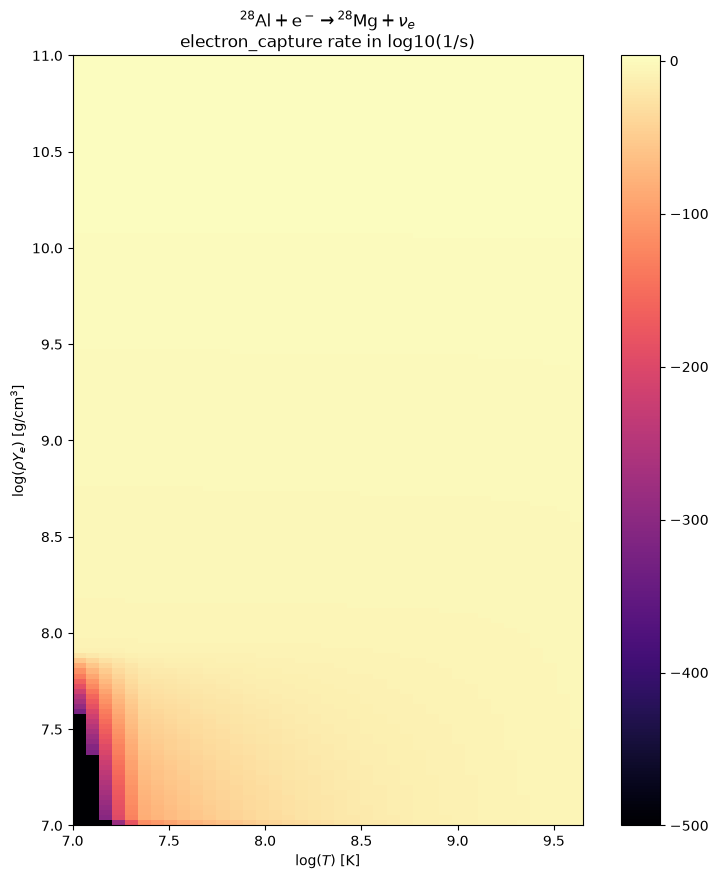

In [6]:
fig = al_mg.plot()

Another example :

In [7]:
ne_f = pyna.load_rate("suzuki-23ne-23f_electroncapture.dat")
print(ne_f)

Ne23 + e⁻ ⟶ F23 + 𝜈


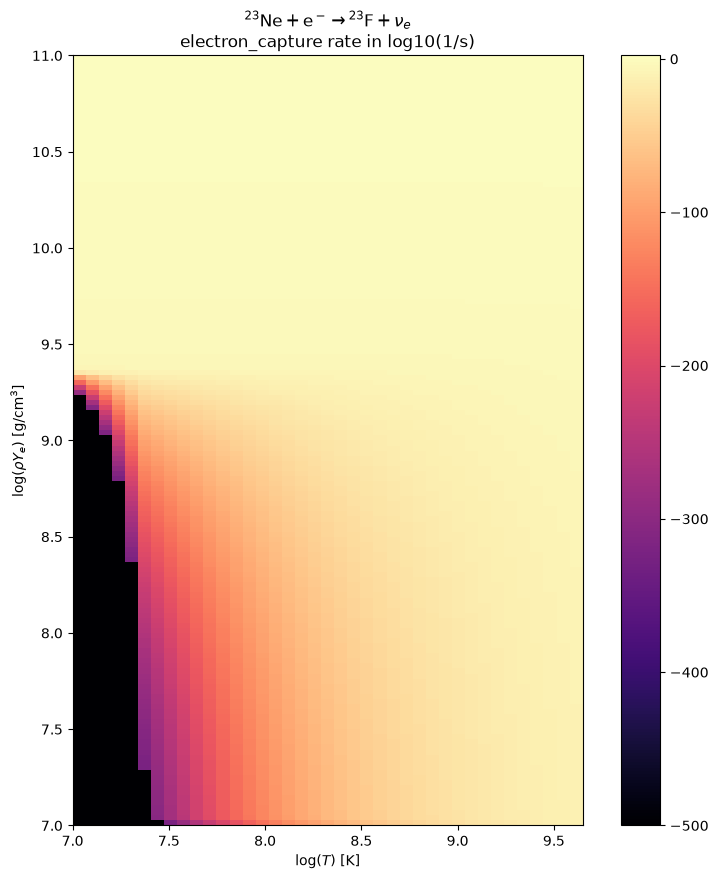

In [8]:
fig = ne_f.plot()

# Working with a group of rates

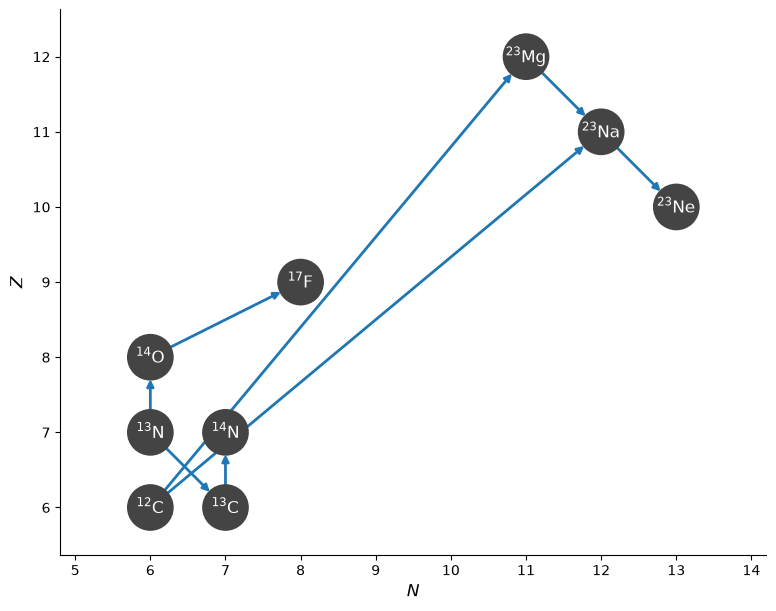

In [10]:
rate_names = ["c13(p,g)n14",
              "n13(,)c13",
              "c12(c12,n)mg23",
              "o14(a,p)f17",
              "n13(p,g)o14",
              "c12(c12,p)na23"]
rl = pyna.ReacLibLibrary()
rates = []
for rn in rate_names:
    rates.append(rl.get_rate_by_name(rn))

sl = pyna.SuzukiLibrary()
rates.append(sl.get_rate_by_name("mg23(,)na23"))
rates.append(sl.get_rate_by_name("na23(,)ne23"))

rc = pyna.RateCollection(rates=rates)
fig = rc.plot()